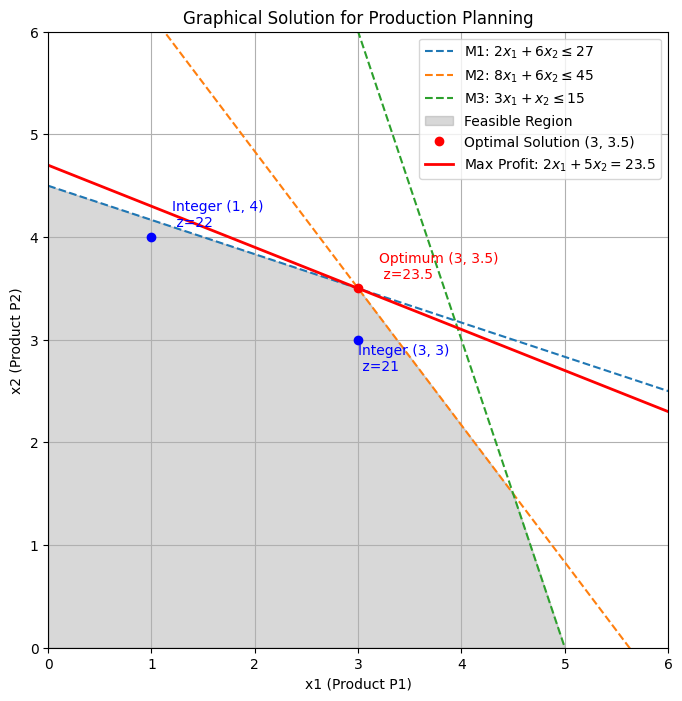

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 設定
x1 = np.linspace(0, 15, 400)

# 制約条件の式 (x2 = ...)
# 1. 2x1 + 6x2 <= 27  ->  x2 <= (27 - 2x1) / 6
y1 = (27 - 2*x1) / 6

# 2. 8x1 + 6x2 <= 45  ->  x2 <= (45 - 8x1) / 6
y2 = (45 - 8*x1) / 6

# 3. 3x1 + x2 <= 15   ->  x2 <= 15 - 3x1
y3 = 15 - 3*x1

# 非負制約も含めた実行可能領域の計算
y_min = np.minimum(np.minimum(y1, y2), y3)
y_feasible = np.maximum(y_min, 0) # x2 >= 0

# グラフ描画
plt.figure(figsize=(8, 8))

# 制約直線の描画
plt.plot(x1, y1, label=r'M1: $2x_1 + 6x_2 \leq 27$', linestyle='--')
plt.plot(x1, y2, label=r'M2: $8x_1 + 6x_2 \leq 45$', linestyle='--')
plt.plot(x1, y3, label=r'M3: $3x_1 + x_2 \leq 15$', linestyle='--')

# 実行可能領域の塗りつぶし
plt.fill_between(x1, 0, y_feasible, where=(y_feasible>=0) & (x1<=5), color='gray', alpha=0.3, label='Feasible Region')

# 最適解の点 (3, 3.5)
plt.plot(3, 3.5, 'ro', label='Optimal Solution (3, 3.5)')
plt.text(3.2, 3.6, 'Optimum (3, 3.5)\n z=23.5', color='red')

# 目的関数 (等利潤線) z = 23.5 の描画
# 2x1 + 5x2 = 23.5 -> x2 = (23.5 - 2x1) / 5
z_max = 23.5
y_obj = (z_max - 2*x1) / 5
plt.plot(x1, y_obj, 'r-', linewidth=2, label=r'Max Profit: $2x_1 + 5x_2 = 23.5$')

# 整数解の検討用の格子点 (3, 3) と (1, 4)
plt.plot(3, 3, 'bo')
plt.text(3, 2.7, 'Integer (3, 3)\n z=21', color='blue')
plt.plot(1, 4, 'bo')
plt.text(1.2, 4.1, 'Integer (1, 4)\n z=22', color='blue')

# グラフ設定
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.xlabel('x1 (Product P1)')
plt.ylabel('x2 (Product P2)')
plt.legend()
plt.grid(True)
plt.title('Graphical Solution for Production Planning')
plt.show()